# Importing Libraries

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tabulate import tabulate

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing

In [3]:
path = r"C:\Users\milam\OneDrive - ALS Bobi\Desktop\FINKI\4 семетстар\machine learning\5_lab\premier league\England CSV.csv"

df = pd.read_csv(path)
df.head()

,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,HTH Goals,HTA Goals,HT Result,...,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order,League
0,16/01/2025,2024/25,Ipswich,Brighton,0,2,A,0.0,1.0,A,...,13.0,14.0,1.0,9.0,2.0,2.0,0.0,0.0,20250116,Premier League
1,16/01/2025,2024/25,Man United,Southampton,3,1,H,0.0,1.0,A,...,7.0,10.0,4.0,4.0,1.0,3.0,0.0,0.0,20250116,Premier League
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,A,0.0,0.0,D,...,17.0,10.0,8.0,5.0,2.0,1.0,0.0,0.0,20250115,Premier League
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,A,0.0,0.0,D,...,7.0,6.0,4.0,3.0,0.0,0.0,0.0,0.0,20250115,Premier League
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,H,1.0,0.0,H,...,10.0,13.0,4.0,2.0,0.0,2.0,0.0,0.0,20250115,Premier League


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12153 entries, 0 to 12152
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           12153 non-null  object 
 1   Season         12153 non-null  object 
 2   HomeTeam       12153 non-null  object 
 3   AwayTeam       12153 non-null  object 
 4   FTH Goals      12153 non-null  int64  
 5   FTA Goals      12153 non-null  int64  
 6   FT Result      12153 non-null  object 
 7   HTH Goals      11229 non-null  float64
 8   HTA Goals      11229 non-null  float64
 9   HT Result      11229 non-null  object 
 10  Referee        9329 non-null   object 
 11  H Shots        9329 non-null   float64
 12  A Shots        9329 non-null   float64
 13  H SOT          9329 non-null   float64
 14  A SOT          9329 non-null   float64
 15  H Fouls        9329 non-null   float64
 16  A Fouls        9329 non-null   float64
 17  H Corners      9329 non-null   float64
 18  A Corn

In [5]:
df.isnull().sum()

Date                0
Season              0
HomeTeam            0
AwayTeam            0
FTH Goals           0
FTA Goals           0
FT Result           0
HTH Goals         924
HTA Goals         924
HT Result         924
Referee          2824
H Shots          2824
A Shots          2824
H SOT            2824
A SOT            2824
H Fouls          2824
A Fouls          2824
H Corners        2824
A Corners        2824
H Yellow         2824
A Yellow         2824
H Red            2824
A Red            2824
Display_Order       0
League              0
dtype: int64

In [6]:
df.describe()

,FTH Goals,FTA Goals,HTH Goals,HTA Goals,H Shots,A Shots,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order
count,12153.000000,12153.000000,11229.000000,11229.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,1.215300e+04
mean,1.531309,1.160948,0.689554,0.511265,13.618716,10.784543,6.007503,4.704684,11.303462,11.781113,6.056383,4.770715,1.462536,1.785722,0.062386,0.085968,2.008629e+07
std,1.306927,1.147714,0.838796,0.731610,5.349420,4.678710,3.275177,2.757288,3.752442,3.931377,3.107327,2.746754,1.215747,1.285168,0.252706,0.291579,9.224046e+04
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.993081e+07
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,9.000000,9.000000,4.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.001010e+07
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,11.000000,12.000000,6.000000,4.000000,1.000000,2.000000,0.000000,0.000000,2.009012e+07
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,14.000000,14.000000,8.000000,6.000000,2.000000,3.000000,0.000000,0.000000,2.017012e+07
max,9.000000,9.000000,5.000000,5.000000,43.000000,31.000000,24.000000,20.000000,33.000000,29.000000,20.000000,19.000000,7.000000,9.000000,3.000000,2.000000,2.025012e+07


In [10]:
df.dropna(inplace=True)
print(df.columns)

Index(['Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTH_Goals', 'FTA_Goals',
       'FT_Result', 'HTH_Goals', 'HTA_Goals', 'HT_Result', 'Referee',
       'H_Shots', 'A_Shots', 'H_SOT', 'A_SOT', 'H_Fouls', 'A_Fouls',
       'H_Corners', 'A_Corners', 'H_Yellow', 'A_Yellow', 'H_Red', 'A_Red',
       'Display_Order', 'League'],
      dtype='object')


### Visualization

<Axes: >

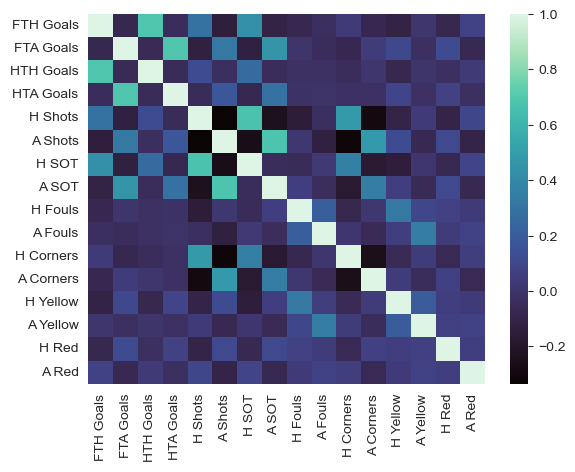

In [10]:
features = df.drop(['Season', 'HomeTeam', 'AwayTeam', 'Date', 'FT Result','HT Result', 'Display_Order', 'League', 'Referee'], axis=1)
sns.heatmap(features.corr(), annot=False, cmap='mako')

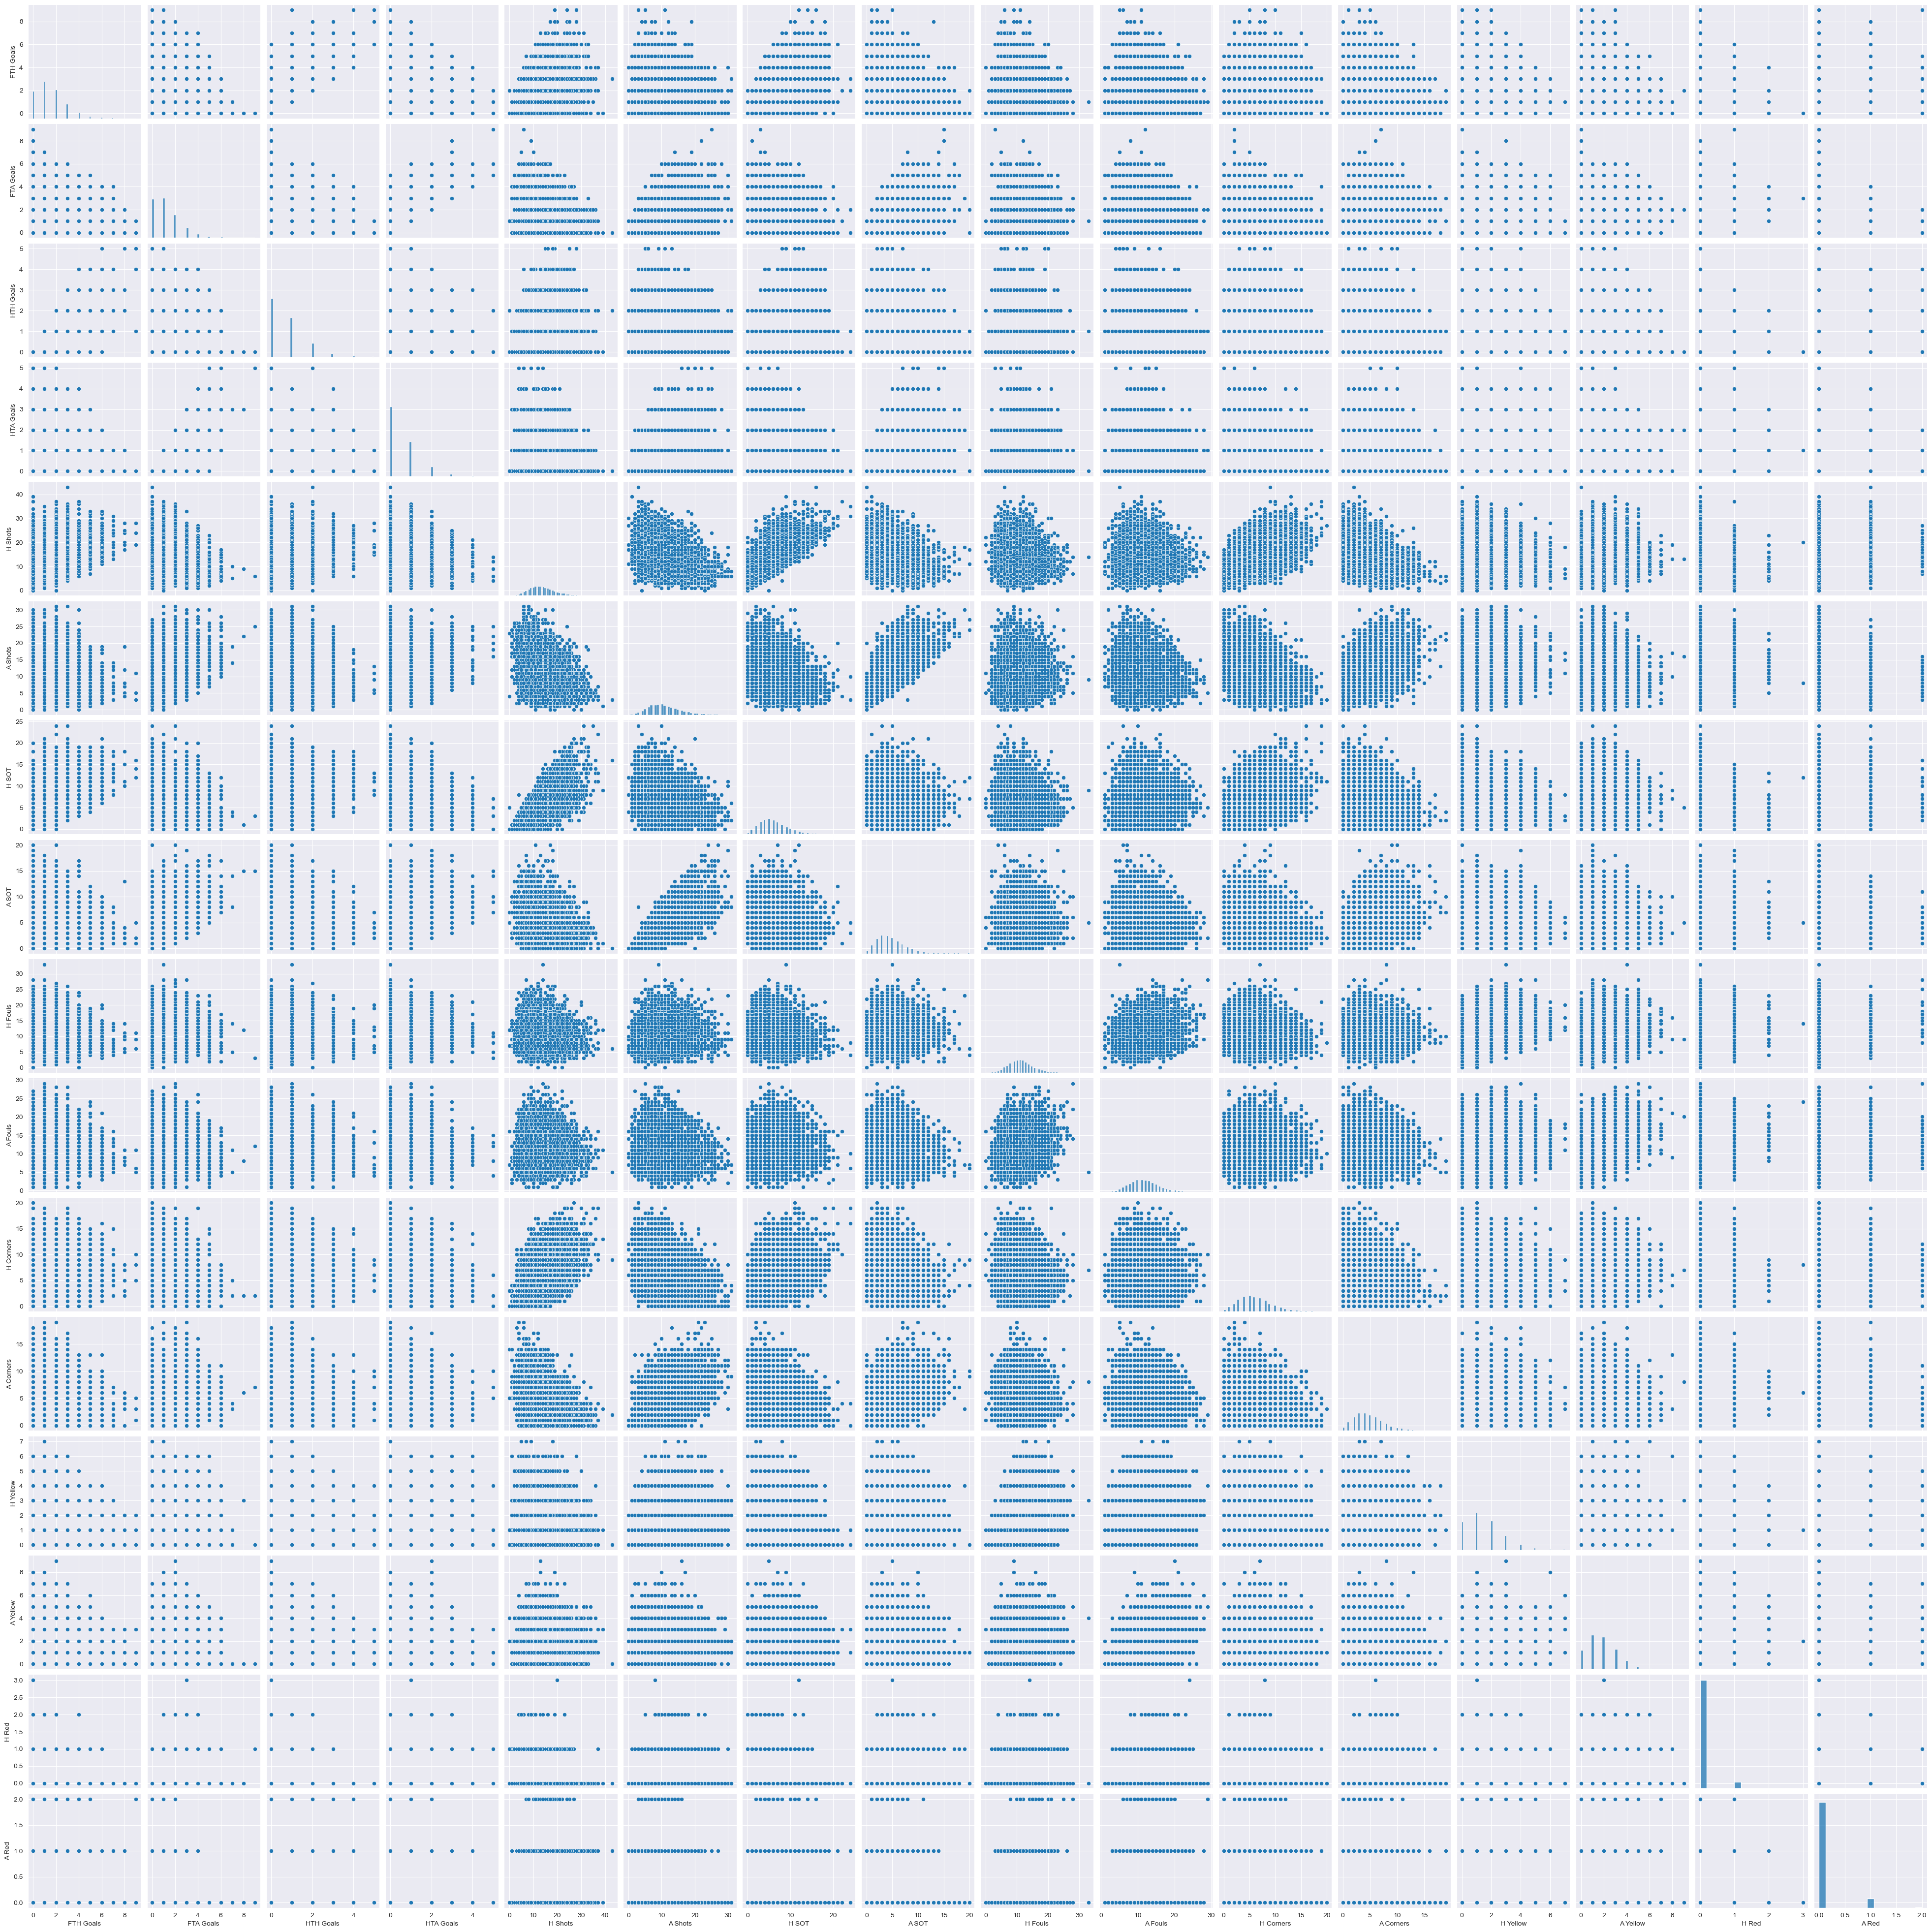

In [11]:
sns.pairplot(features)

### Summarizing total points per team per season

In [11]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
def compute_team_season_stats(df):
    teams = set(df['HomeTeam']).union(df['AwayTeam'])
    seasons = df['Season'].unique()
    team_season_stats = []

    for season in seasons:
        season_df = df[df['Season'] == season]

        for team in teams:
            team_matches = season_df[(season_df['HomeTeam'] == team) | (season_df['AwayTeam'] == team)]

            points, goals_scored, goals_conceded = 0, 0, 0
            shots, shots_on_target = 0, 0
            fouls, corners, yellow_cards, red_cards = 0, 0, 0, 0
            matches_played = len(team_matches)
            if matches_played > 0:
                for _, row in team_matches.iterrows():
                    if row['HomeTeam'] == team:
                        goals_scored += row['FTH_Goals']
                        goals_conceded += row['FTA_Goals']
                        shots += row['H_Shots']
                        shots_on_target += row['H_SOT']
                        fouls += row['H_Fouls']
                        corners += row['H_Corners']
                        yellow_cards += row['H_Yellow']
                        red_cards += row['H_Red']
                        if row['FT_Result'] == 'H':
                            points += 3
                        elif row['FT_Result'] == 'D':
                            points += 1
                    else:
                        goals_scored += row['FTA_Goals']
                        goals_conceded += row['FTH_Goals']
                        shots += row['A_Shots']
                        shots_on_target += row['A_SOT']
                        fouls += row['A_Fouls']
                        corners += row['A_Corners']
                        yellow_cards += row['A_Yellow']
                        red_cards += row['A_Red']
                        if row['FT_Result'] == 'A':
                            points += 3
                        elif row['FT_Result'] == 'D':
                            points += 1

                team_season_stats.append({
                    'Season': season,
                    'Team': team,
                    'Matches': matches_played,
                    'Points': points,
                    'Goals_Scored': goals_scored,
                    'Goals_Conceded': goals_conceded,
                    'Shots': shots,
                    'Shots_on_Target': shots_on_target,
                    'Fouls': fouls,
                    'Corners': corners,
                    'Yellow_Cards': yellow_cards,
                    'Red_Cards': red_cards,
                })

    return pd.DataFrame(team_season_stats)


team_season_df = compute_team_season_stats(df)
team_season_df

,Season,Team,Matches,Points,Goals_Scored,Goals_Conceded,Shots,Shots_on_Target,Fouls,Corners,Yellow_Cards,Red_Cards
0,2024/25,Chelsea,21,37,41,26,341.0,129.0,253.0,132.0,59.0,1.0
1,2024/25,Brighton,21,31,32,29,304.0,102.0,253.0,109.0,42.0,1.0
2,2024/25,West Ham,21,26,27,41,296.0,90.0,242.0,100.0,48.0,2.0
3,2024/25,Fulham,21,30,32,30,293.0,103.0,233.0,112.0,50.0,2.0
4,2024/25,Aston Villa,21,35,31,32,268.0,88.0,243.0,138.0,43.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
495,2000/01,Man United,38,80,79,31,556.0,264.0,433.0,269.0,44.0,3.0
496,2000/01,Everton,38,42,45,59,394.0,195.0,558.0,203.0,74.0,5.0
497,2000/01,Middlesbrough,38,42,44,44,352.0,167.0,498.0,146.0,72.0,6.0
498,2000/01,Sunderland,38,57,46,41,449.0,218.0,618.0,187.0,73.0,5.0


<Axes: >

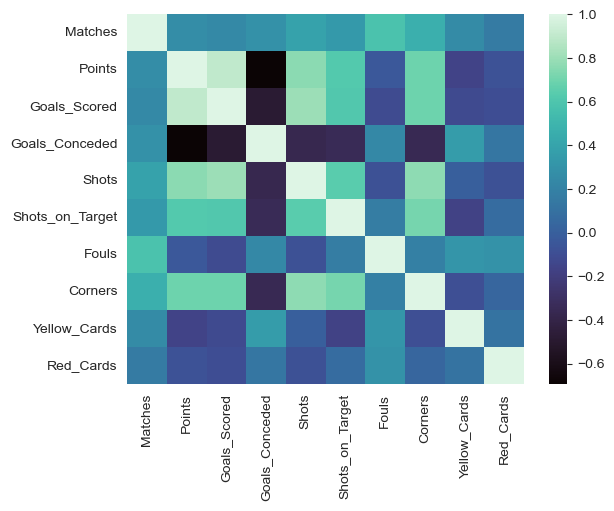

In [29]:
features = team_season_df.drop(["Season", "Team"], axis=1)
sns.heatmap(features.corr(), annot=False, cmap='mako')

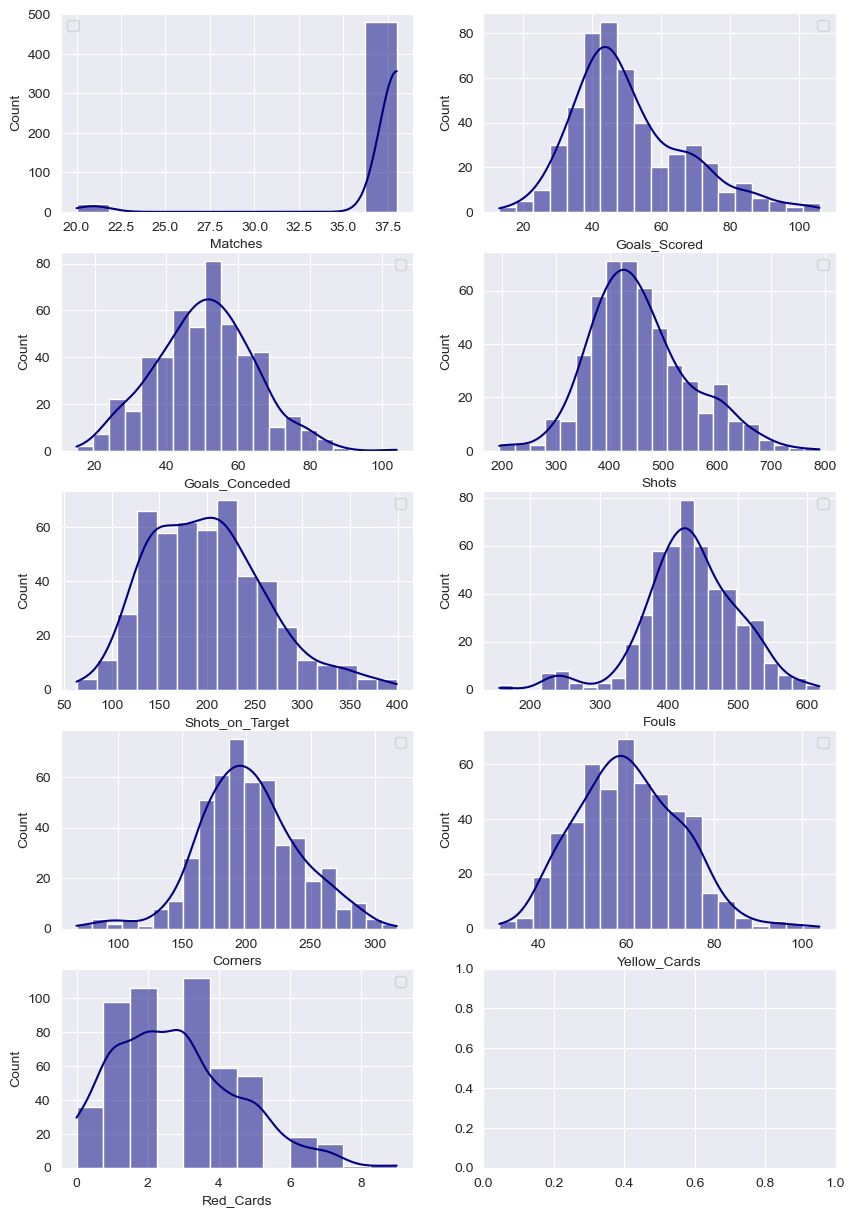

In [44]:
target=team_season_df["Points"]
input_features=team_season_df.drop(["Season", "Team", "Points"], axis=1)
feature_names=["Matches", "Goals_Scored", "Goals_Conceded", "Shots", "Shots_on_Target", "Fouls", "Corners", "Yellow_Cards", "Red_Cards"]
fig = plt.figure(figsize=(10, 15))
fig.subplots(nrows=5, ncols=2)
for feat_i in range(input_features.shape[1]):
    ax = plt.subplot(5,2, feat_i+1)
    sns.histplot(input_features.iloc[:,feat_i],color='navy',kde=True,stat="count")
    plt.legend()
plt.show()

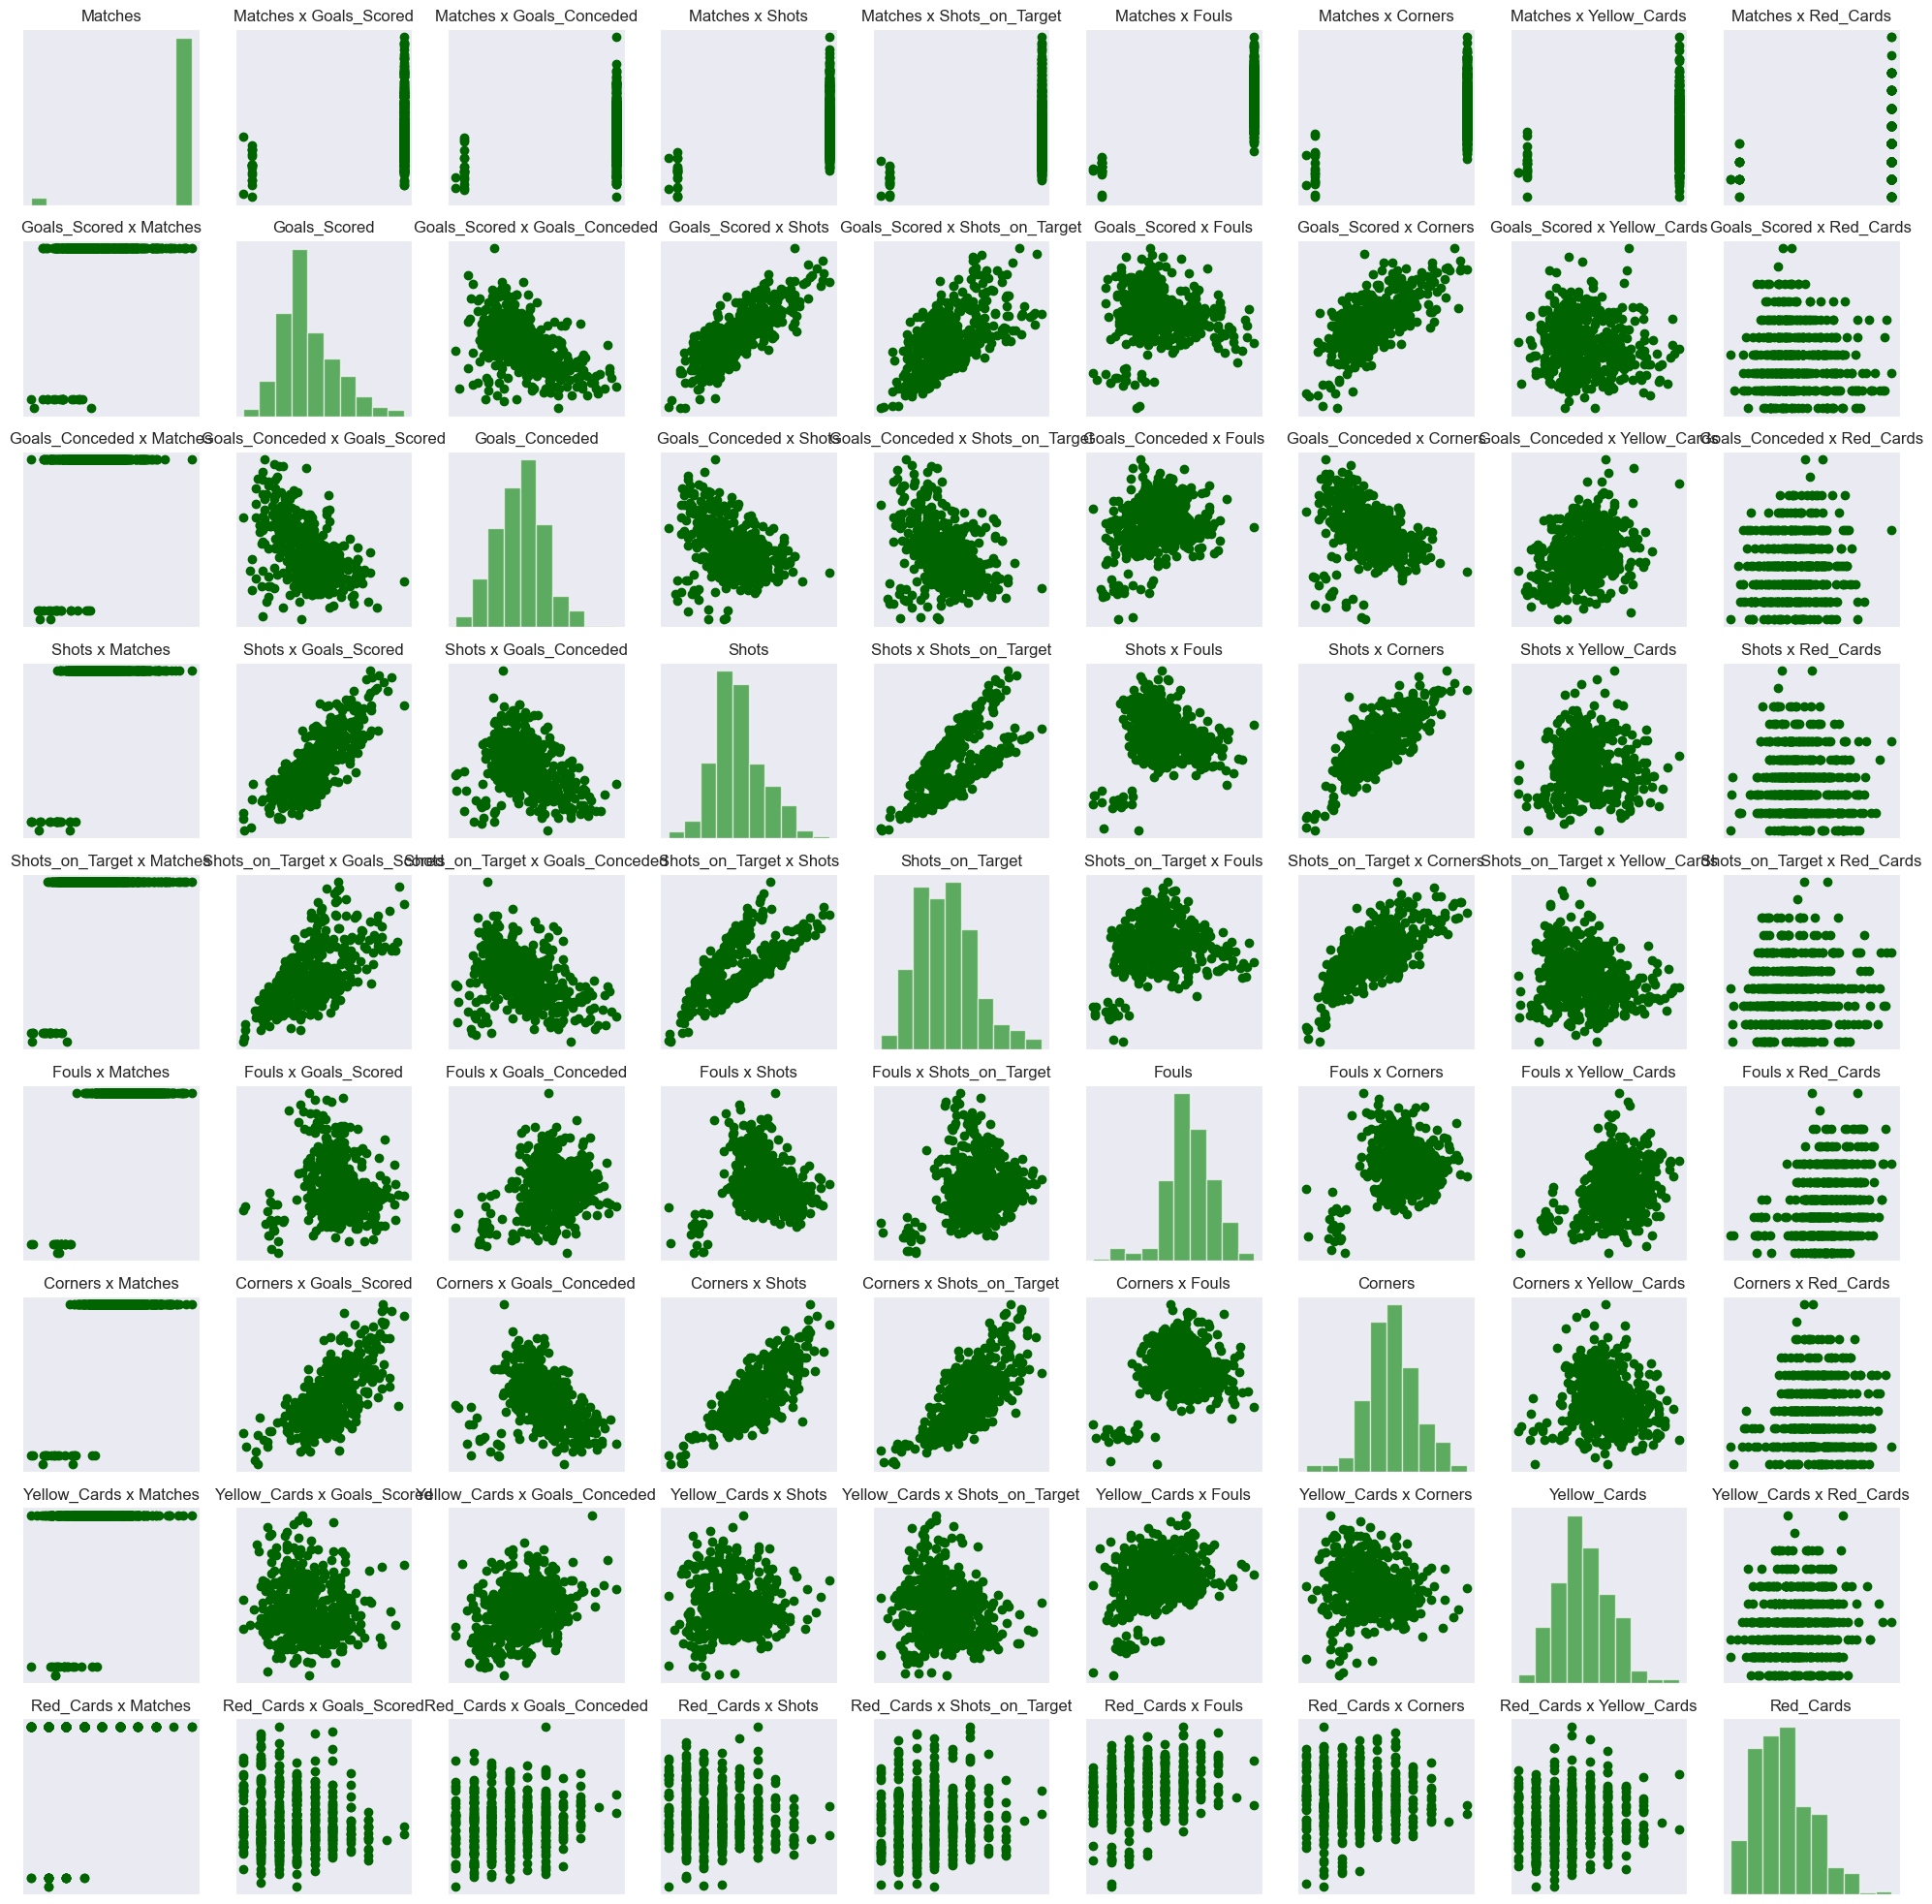

In [49]:
number_of_features = input_features.shape[1]
fig = plt.figure(figsize=(25, 25))
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
          plt.hist(input_features.iloc[:, feature_i], alpha=.6, color="green")
          plt.title(feature_names[feature_i])
        else:
          plt.scatter(input_features.iloc[:,feature_i], input_features.iloc[:,feature_j], color="darkgreen")
          plt.title(feature_names[feature_i]+" x "+feature_names[feature_j])
        plt.xticks(())
        plt.yticks(())
plt.show()

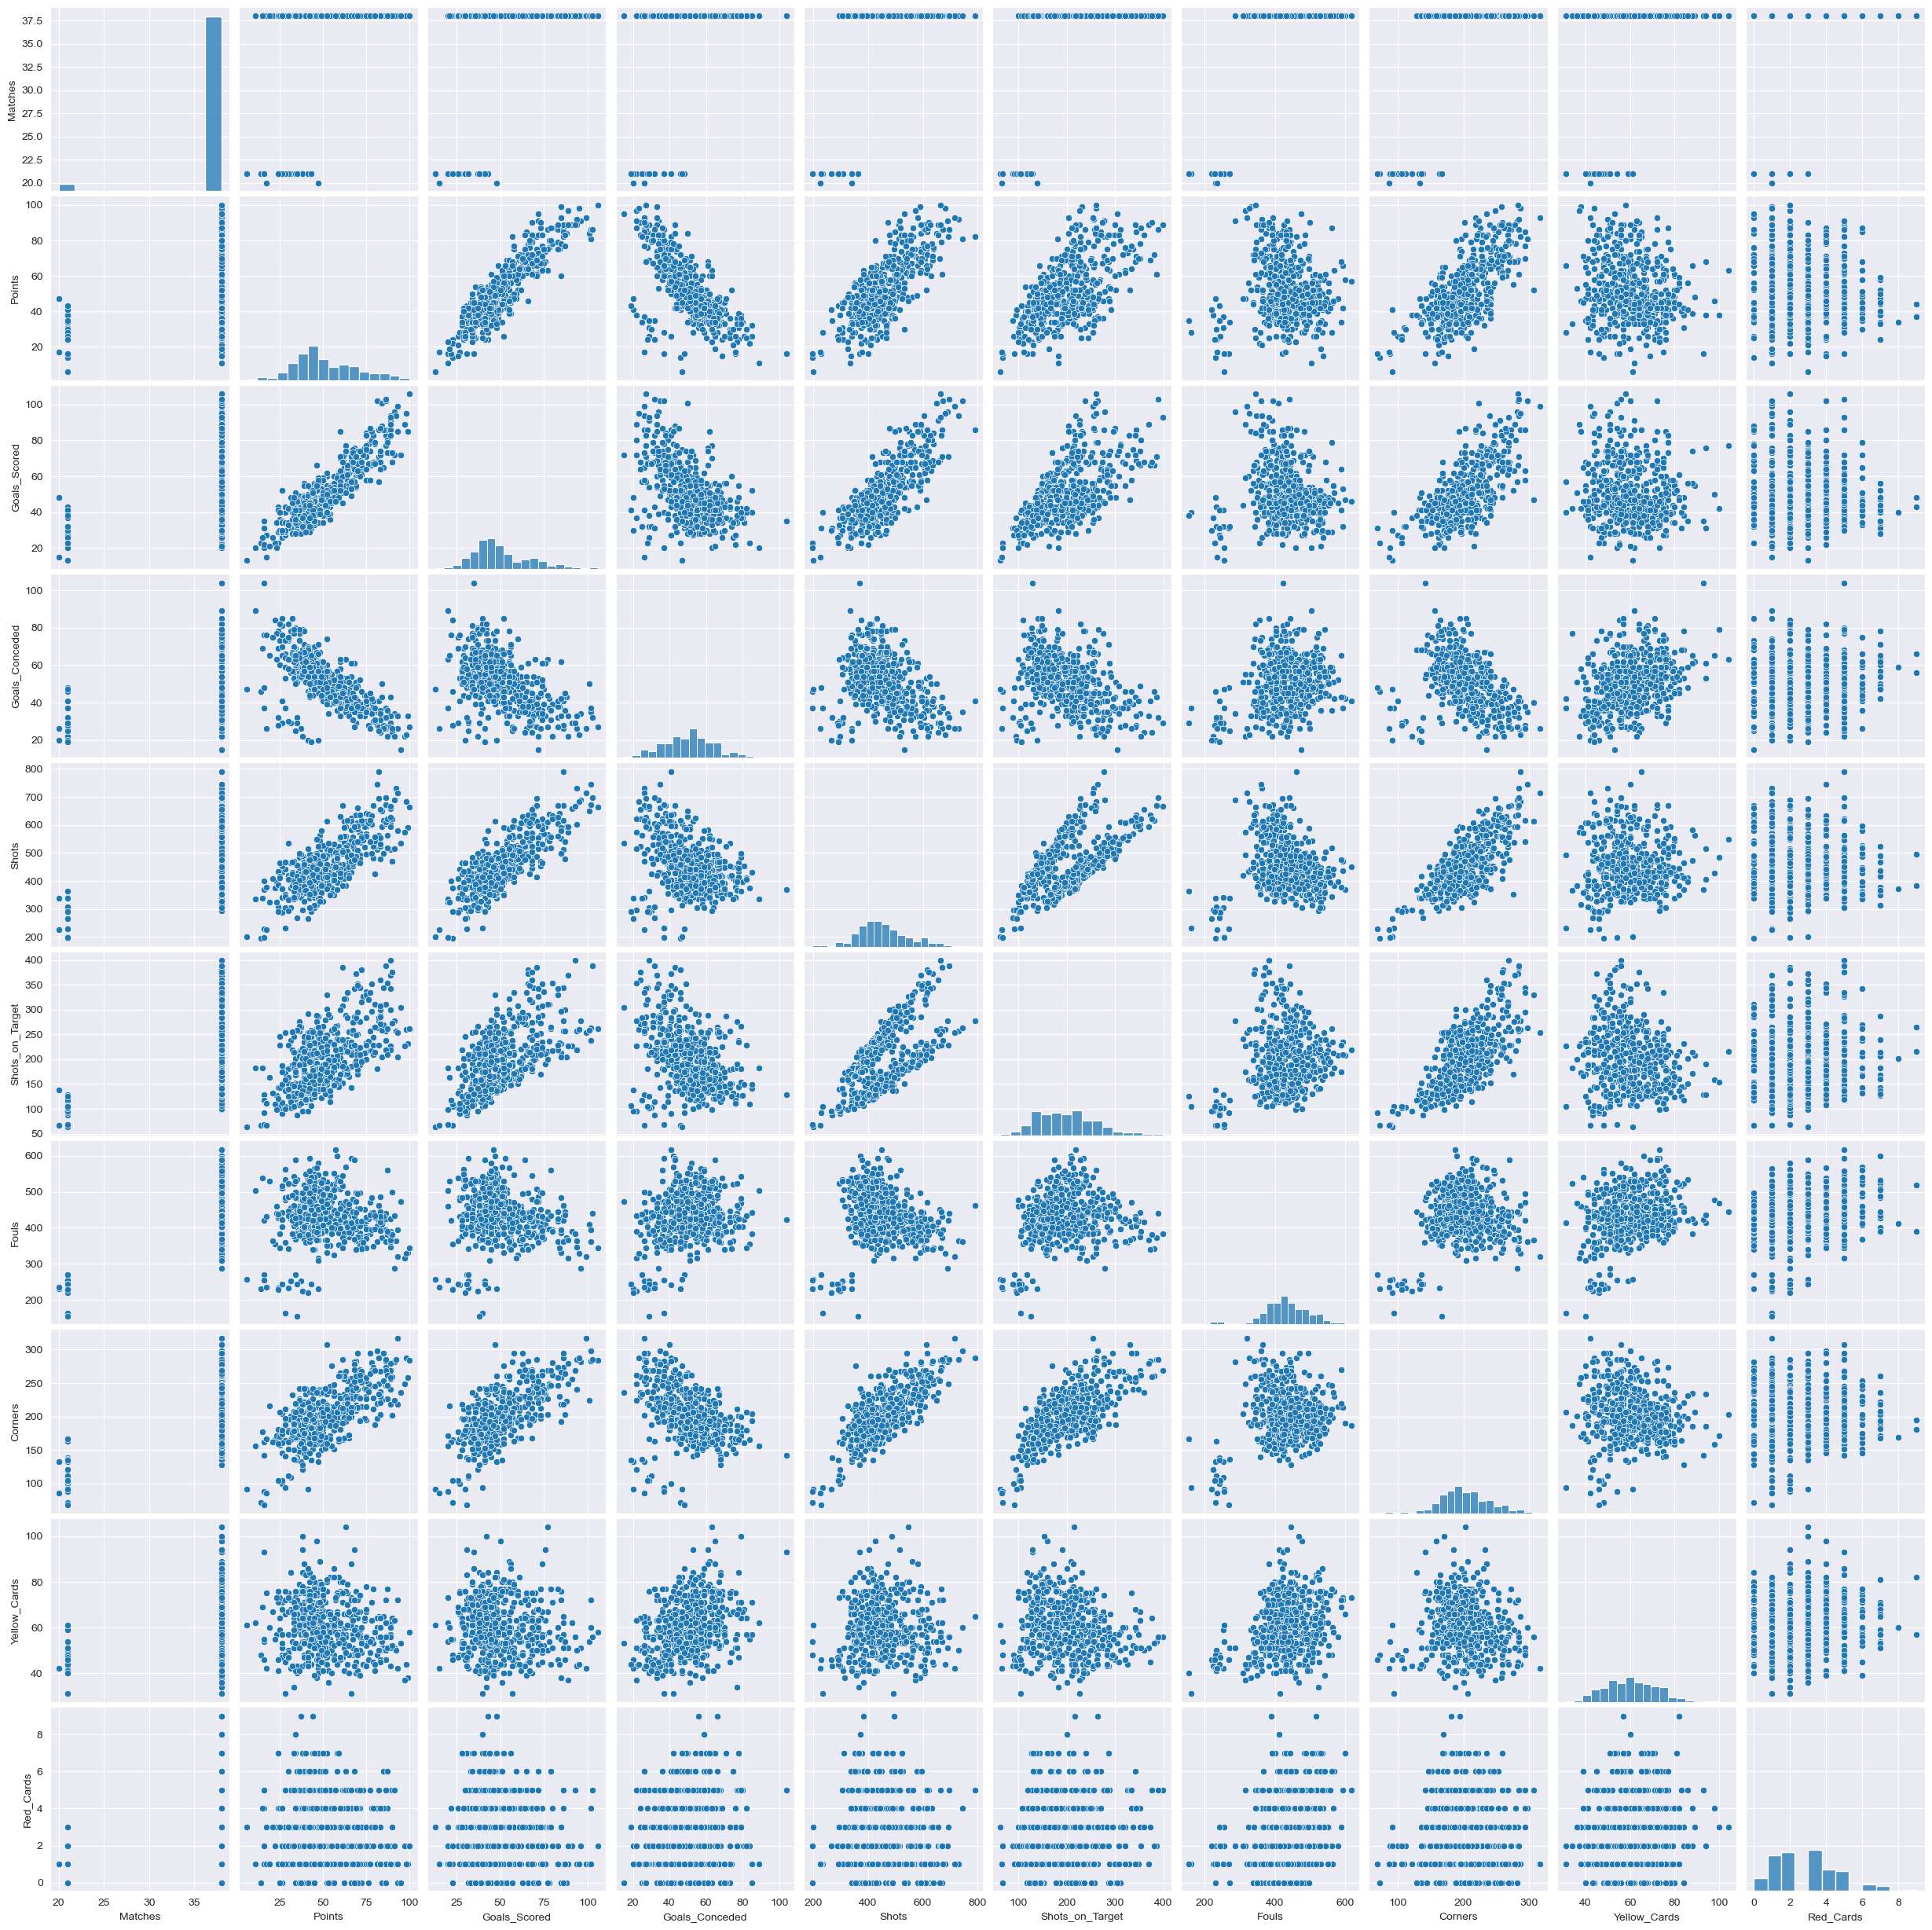

In [30]:
sns.pairplot(features)

# Models for Regression

In [15]:
train_df = team_season_df[team_season_df['Season']!= "2024/25"]
test_df = team_season_df[team_season_df['Season'] == "2024/25"]
X_train = train_df.drop(['Season', 'Team', 'Points'], axis=1)
y_train = train_df['Points']
X_test = test_df.drop(['Season', 'Team', 'Points'], axis=1)
y_test=[
    69,  # Chelsea
    61,  # Brighton
    43,  # West Ham
    54,  # Fulham
    66,  # Aston Villa
    66,  # Newcastle
    25,  # Leicester
    56,  # Brentford
    84,  # Liverpool
    42,  # Wolves
    38,  # Tottenham
    12,  # Southampton
    22,  # Ipswich
    65,  # Nott'm Forest
    56,  # Bournemouth
    74,  # Arsenal
    42,  # Man United
    53,  # Crystal Palace
    48,  # Everton
    71   # Man City
]

In [16]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

MSE for Linear Regression: 114.1906194070402
MAE for Linear Regression: 8.080175464014408
R2 for Linear Regression: 0.6516746782773251


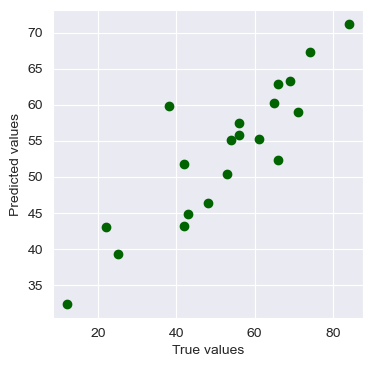

In [17]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
predictions_lr = lr.predict(X_test_scaled)
mse_lr = mean_squared_error(y_test, predictions_lr)
mae_lr = mean_absolute_error(y_test, predictions_lr)
r2_lr = r2_score(y_test, predictions_lr)
print("MSE for Linear Regression:", mse_lr)
print("MAE for Linear Regression:", mae_lr)
print("R2 for Linear Regression:", r2_lr)

plt.figure(figsize=(4, 4))
plt.scatter(y_test,predictions_lr, color="darkgreen")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

### Linear Ridge Regression

MSE for Linear Ridge Regression: 113.74718478256939
MAE for Linear Ridge Regression: 8.154611175436042
R2 for Linear Ridge Regression: 0.653027324484464


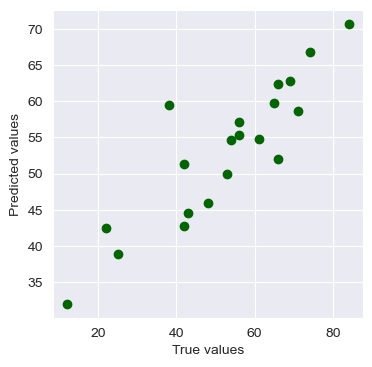

In [18]:
lr_ridge = RidgeCV()
lr_ridge.fit(X_train_scaled, y_train)
predictions_ridge = lr_ridge.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, predictions_ridge)
mae_ridge = mean_absolute_error(y_test, predictions_ridge)
r2_ridge = r2_score(y_test, predictions_ridge)
print("MSE for Linear Ridge Regression:", mse_ridge)
print("MAE for Linear Ridge Regression:", mae_ridge)
print("R2 for Linear Ridge Regression:", r2_ridge)

plt.figure(figsize=(4, 4))
plt.scatter(y_test,predictions_ridge, color="darkgreen")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

### Linear Lasso Regression

MSE for Linear Lasso Regression: 114.40401360734427
MAE for Linear Lasso Regression: 8.468752976620014
R2 for Linear Lasso Regression: 0.6510237438672952


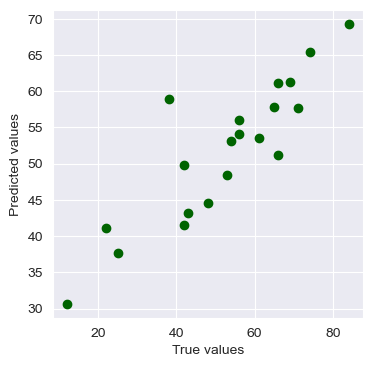

In [19]:
lr_lasso = LassoCV()
lr_lasso.fit(X_train_scaled, y_train)
predictions_lr_lasso = lr_lasso.predict(X_test_scaled)
mse_lasso = mean_squared_error(y_test, predictions_lr_lasso)
mae_lasso = mean_absolute_error(y_test, predictions_lr_lasso)
r2_lasso= r2_score(y_test, predictions_lr_lasso)
print("MSE for Linear Lasso Regression:", mse_lasso)
print("MAE for Linear Lasso Regression:", mae_lasso)
print("R2 for Linear Lasso Regression:", r2_lasso)

plt.figure(figsize=(4, 4))
plt.scatter(y_test,predictions_lr_lasso, color="darkgreen")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

### Elastic Net Regression

MSE for Elastic Net: 128.9172888829156
MAE for Elastic Net: 9.92412040551957
R2 for Elastic Net: 0.6067526705876853


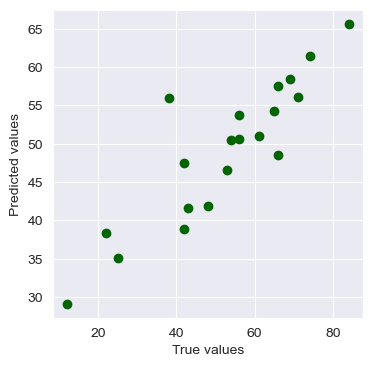

In [20]:
lr_elastic = ElasticNetCV()
lr_elastic.fit(X_train_scaled, y_train)
predictions_lr_elastic = lr_elastic.predict(X_test_scaled)
mse_elastic = mean_squared_error(y_test, predictions_lr_elastic)
mae_elastic = mean_absolute_error(y_test, predictions_lr_elastic)
r2_elastic= r2_score(y_test, predictions_lr_elastic)
print("MSE for Elastic Net:", mse_elastic)
print("MAE for Elastic Net:", mae_elastic)
print("R2 for Elastic Net:", r2_elastic)

plt.figure(figsize=(4, 4))
plt.scatter(y_test,predictions_lr_elastic, color="darkgreen")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

### Bayesian Regression

MSE for Bayesian Regression: 114.03943488142868
MAE for Bayesian Regression: 8.099320470734096
R2 for Bayesian Regression: 0.6521358492456286


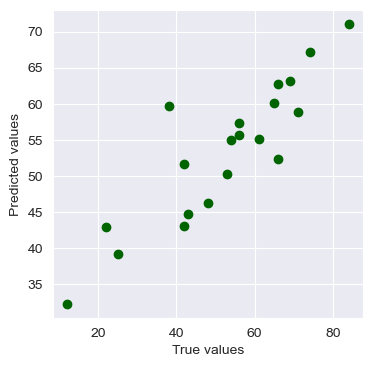

In [21]:
bayes = BayesianRidge()
bayes.fit(X_train_scaled, y_train)
predictions_bayes = bayes.predict(X_test_scaled)
mse_bayes = mean_squared_error(y_test, predictions_bayes)
mae_bayes = mean_absolute_error(y_test, predictions_bayes)
r2_bayes= r2_score(y_test, predictions_bayes)
print("MSE for Bayesian Regression:", mse_bayes)
print("MAE for Bayesian Regression:", mae_bayes)
print("R2 for Bayesian Regression:", r2_bayes)

plt.figure(figsize=(4, 4))
plt.scatter(y_test,predictions_bayes, color="darkgreen")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.show()

## Support Vector Regressor

MSE for Support Vector Regressor: 113.67647562689066
MAE for Support Vector Regressor: 8.310095944185388
R2 for Support Vector Regressor: 0.6532430146132016
Best Params: {'svr__C': 100, 'svr__epsilon': 1, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}


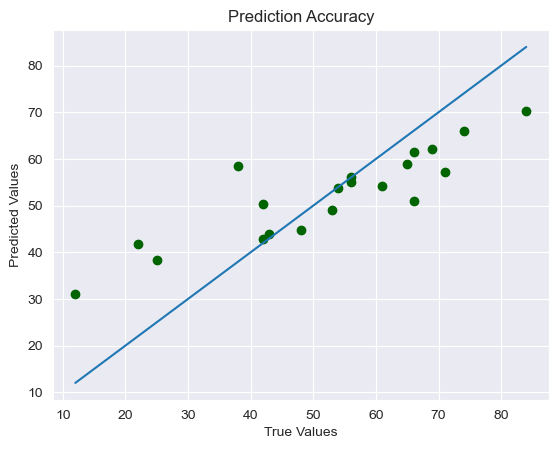

In [23]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__C': [0.1, 1, 10, 100, 500],
    'svr__epsilon': [0.01, 0.1, 1, 5],
    'svr__gamma': ['scale', 'auto'],
    'svr__kernel': ['rbf', 'linear' , 'poly']
}


grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

best_svr = grid.best_estimator_

predictions_svr = best_svr.predict(X_test)
mse_svr = mean_squared_error(y_test, predictions_svr)
mae_svr = mean_absolute_error(y_test, predictions_svr)
r2_svr= r2_score(y_test, predictions_svr)
print("MSE for Support Vector Regressor:", mse_svr)
print("MAE for Support Vector Regressor:", mae_svr)
print("R2 for Support Vector Regressor:", r2_svr)

print("Best Params:", grid.best_params_)

plt.scatter(y_test, predictions_svr, color="darkgreen")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Accuracy")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.show()

## Foundational Models

### Decision Tree Regressor

MSE for Decision Tree Regressor: 244.0
MAE for Decision Tree Regressor: 12.6
R2 for Decision Tree Regressor: 0.25570612593513364
Best Params: {'criterion': 'absolute_error', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


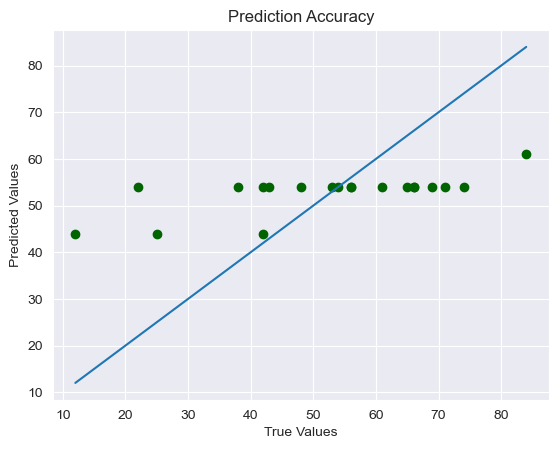

In [24]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
}

grid = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid,cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

predictions_dt = best_dt.predict(X_test)
mse_dt = mean_squared_error(y_test, predictions_dt)
mae_dt = mean_absolute_error(y_test, predictions_dt)
r2_dt= r2_score(y_test, predictions_dt)
print("MSE for Decision Tree Regressor:", mse_dt)
print("MAE for Decision Tree Regressor:", mae_dt)
print("R2 for Decision Tree Regressor:", r2_dt)
print("Best Params:", grid.best_params_)

plt.scatter(y_test, predictions_dt, color="darkgreen")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Accuracy")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.show()

### Random Forest Regressor

MSE for Random Forest Regressor: 260.4037075624733
MAE for Random Forest Regressor: 14.014753427128431
R2 for Random Forest Regressor: 0.20566850687488603


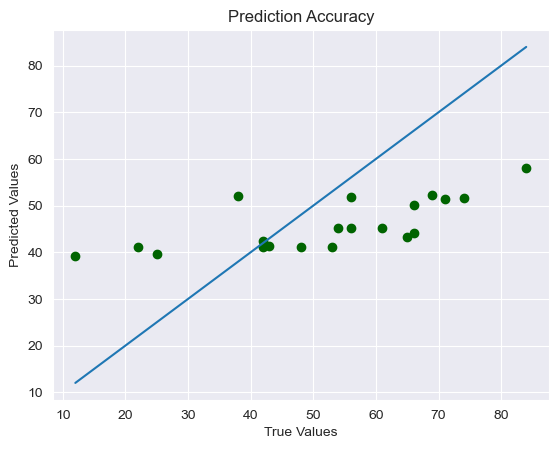

In [25]:
param_grid = {
    'max_depth': [3, 5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

predictions_rf = best_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, predictions_rf)
mae_rf = mean_absolute_error(y_test, predictions_rf)
r2_rf= r2_score(y_test, predictions_rf)
print("MSE for Random Forest Regressor:", mse_rf)
print("MAE for Random Forest Regressor:", mae_rf)
print("R2 for Random Forest Regressor:", r2_rf)

plt.scatter(y_test, predictions_rf, color="darkgreen")
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Accuracy")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.show()

### Neural Network for Regression

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
MSE for Neural Network: 33455.17384889645
MAE for Neural Network: 182.406787109375
R2 for Neural Network: -101.05116271972656


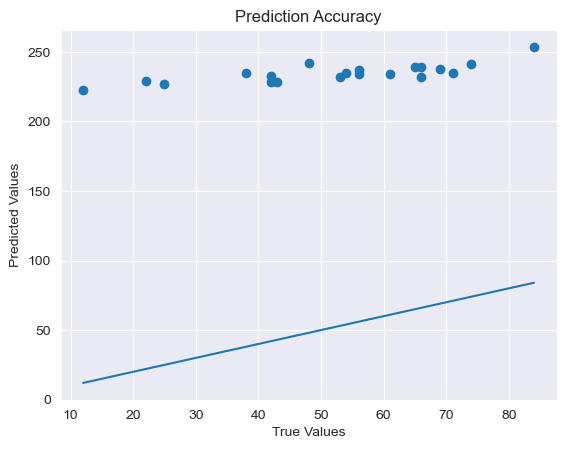

In [27]:
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

nn_model.compile(optimizer='adam', loss='mse')
history = nn_model.fit(X_train_scaled, y_train, epochs=300, batch_size=4, validation_split=0.2, verbose=0)
predictions_nn = nn_model.predict(X_test_scaled).flatten()

mse_nn = mean_squared_error(y_test, predictions_nn)
mae_nn = mean_absolute_error(y_test, predictions_nn)
r2_nn= r2_score(y_test, predictions_nn)
print("MSE for Neural Network:", mse_nn)
print("MAE for Neural Network:", mae_nn)
print("R2 for Neural Network:", r2_nn)

plt.scatter(y_test, predictions_nn)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Accuracy")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.show()

# Comparison

In [28]:
comparison_df = test_df[['Team']].copy()
comparison_df['Real Points'] = y_test
comparison_df['LR_Pred'] = predictions_lr
comparison_df['LR_Ridge_Pred'] = predictions_ridge
comparison_df['LR_Lasso_Pred'] = predictions_lr_lasso
comparison_df['LR_ElasticNet_Pred'] = predictions_lr_elastic
comparison_df['Bayesian_Pred'] = predictions_bayes
comparison_df['SVR_Pred'] = predictions_svr
comparison_df['DT_Pred'] = predictions_dt
comparison_df['RF_Pred'] = predictions_rf
comparison_df['NN_Pred'] = predictions_nn

comparison_df['Avg_Pred'] = comparison_df[['LR_Pred', 'RF_Pred', 'NN_Pred', 'DT_Pred', 'LR_Ridge_Pred', 'LR_Lasso_Pred', 'LR_ElasticNet_Pred', 'SVR_Pred', 'Bayesian_Pred']].mean(axis=1)

comparison_df = comparison_df.sort_values('Real Points', ascending=False)

print(tabulate(comparison_df.head(20), headers='keys', tablefmt='pretty'))

+----+----------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------+--------------------+--------------------+--------------------+
|    |      Team      | Real Points |      LR_Pred       |   LR_Ridge_Pred    |   LR_Lasso_Pred    | LR_ElasticNet_Pred |   Bayesian_Pred    |      SVR_Pred      | DT_Pred |      RF_Pred       |      NN_Pred       |      Avg_Pred      |
+----+----------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+---------+--------------------+--------------------+--------------------+
| 8  |   Liverpool    |     84      | 71.22608399071545  | 70.70714346008911  | 69.32541070475635  |  65.6567851201928  | 71.09236452071465  | 70.22245482013227  |  61.0   | 58.15708333333332  | 253.5435791015625  | 87.88121167238849  |
| 15 |    Arsenal     |     74      | 67.32303387802